# Taobao User Behavior: Dataset Exploration & Behavior Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
[![Download Data](https://img.shields.io/badge/Download-Taobao%20Dataset-blue)](https://tianchi.aliyun.com/dataset/dataDetail?dataId=649)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the structure and scale of the Taobao User Behavior dataset
2. **Analyze** user behavior patterns including conversion funnels, temporal dynamics, and engagement distributions
3. **Identify** the long-tail phenomena in item popularity and user activity
4. **Explain** why sequential modeling is particularly suited for this type of user behavior data
5. **Preprocess** the raw data into sequences ready for DIN, BST, and SASRec models

## Prerequisites

- Python 3.8+
- pandas, numpy, matplotlib, seaborn
- Basic understanding of recommender system data formats

## Dataset Overview

The **Taobao User Behavior** dataset contains ~100 million records of user interactions on Taobao (Alibaba's e-commerce platform) over a 9-day window (Nov 25 - Dec 3, 2017).

| Column | Description |
|--------|------------|
| `user_id` | Anonymized user identifier |
| `item_id` | Anonymized item identifier |
| `category_id` | Category of the item |
| `behavior_type` | Type of behavior: `pv`, `buy`, `cart`, `fav` |
| `timestamp` | Unix timestamp of the interaction |

## 0. Setup and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from collections import Counter
import warnings
import os
import pickle

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

# Data path
DATA_PATH = '../../data/taobao/UserBehavior.csv'
PROCESSED_DIR = '../../data/taobao/processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load and Inspect the Data

> **Concept:** The Taobao dataset is a large-scale implicit feedback dataset. Unlike explicit ratings (1-5 stars), we observe *behavioral signals* such as page views, add-to-cart, favorites, and purchases. The temporal ordering of these behaviors forms **behavior sequences** that encode user intent.

We sample ~10M rows to keep exploration fast while retaining statistical representativeness.

In [2]:
# Load data - the CSV has no header
column_names = ['user_id', 'item_id', 'category_id', 'behavior_type', 'timestamp']

print('Loading Taobao User Behavior data...')
# Read 10M rows for exploration
df = pd.read_csv(
    DATA_PATH, 
    header=None, 
    names=column_names,
    nrows=10_000_000
)

print(f'Loaded {len(df):,} rows')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(10)

Loading Taobao User Behavior data...


Loaded 10,000,000 rows


Memory usage: 911.6 MB


,user_id,item_id,category_id,behavior_type,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146
5,1,4606018,2735466,pv,1511616481
6,1,230380,411153,pv,1511644942
7,1,3827899,2920476,pv,1511713473
8,1,3745169,2891509,pv,1511725471
9,1,1531036,2920476,pv,1511733732


In [3]:
# Convert timestamp to datetime
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Monday

print(f'Date range: {df["datetime"].min()} to {df["datetime"].max()}')
print(f'\nData types:')
print(df.dtypes)
print(f'\nNull values:')
print(df.isnull().sum())

Date range: 1905-07-13 13:54:07 to 2037-04-09 05:22:35

Data types:
user_id                  int64
item_id                  int64
category_id              int64
behavior_type              str
timestamp                int64
datetime         datetime64[s]
date                    object
hour                     int32
day_of_week              int32
dtype: object

Null values:


user_id          0
item_id          0
category_id      0
behavior_type    0
timestamp        0
datetime         0
date             0
hour             0
day_of_week      0
dtype: int64


## 2. Basic Statistics

In [4]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_categories = df['category_id'].nunique()
n_interactions = len(df)
sparsity = 1.0 - n_interactions / (n_users * n_items)

print('='*50)
print('       Taobao User Behavior - Basic Statistics')
print('='*50)
print(f'  Total interactions:   {n_interactions:>12,}')
print(f'  Unique users:         {n_users:>12,}')
print(f'  Unique items:         {n_items:>12,}')
print(f'  Unique categories:    {n_categories:>12,}')
print(f'  Avg interactions/user:{n_interactions/n_users:>12.1f}')
print(f'  Avg interactions/item:{n_interactions/n_items:>12.1f}')
print(f'  Sparsity:             {sparsity:>12.6f}')
print('='*50)

       Taobao User Behavior - Basic Statistics
  Total interactions:     10,000,000
  Unique users:               97,811
  Unique items:            1,561,016
  Unique categories:           7,967
  Avg interactions/user:       102.2
  Avg interactions/item:         6.4
  Sparsity:                 0.999935


## 3. Behavior Type Analysis

> **Concept:** E-commerce platforms track multiple types of user interactions. The *conversion funnel* — from browsing (page view) to purchase — reveals user intent progression. Understanding this funnel is critical for defining prediction tasks (e.g., CTR, conversion rate prediction).

Behavior Type Distribution:
    pv:  8,950,064 (89.50%)
   fav:    291,657 ( 2.92%)
  cart:    559,132 ( 5.59%)
   buy:    199,147 ( 1.99%)


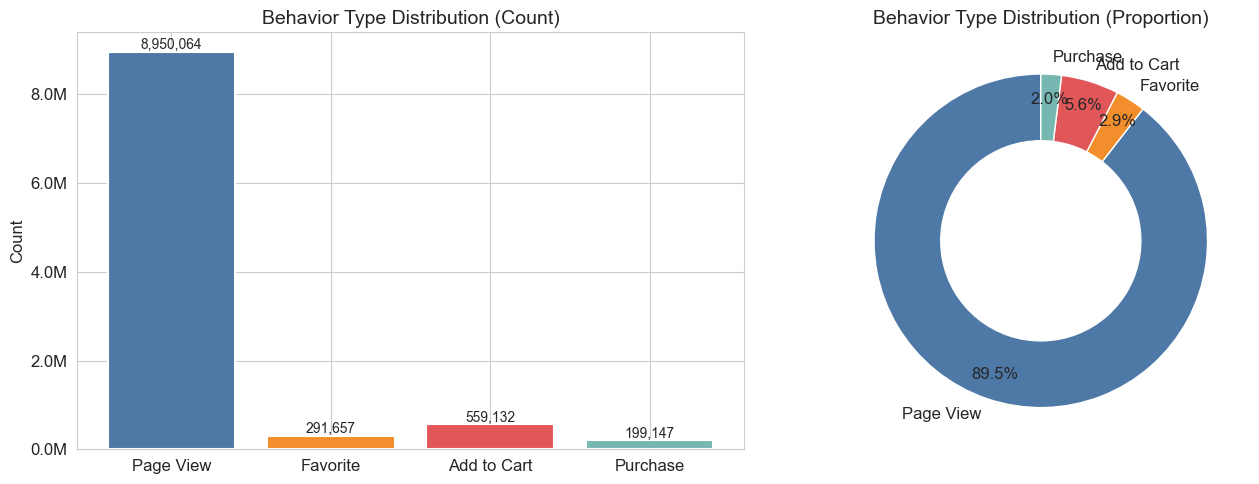

Figure 1 saved.


In [5]:
# Behavior distribution
behavior_counts = df['behavior_type'].value_counts()
behavior_pcts = df['behavior_type'].value_counts(normalize=True) * 100

print('Behavior Type Distribution:')
for btype in ['pv', 'fav', 'cart', 'buy']:
    if btype in behavior_counts.index:
        print(f'  {btype:>4s}: {behavior_counts[btype]:>10,} ({behavior_pcts[btype]:5.2f}%)')

# ----- Fig 1: Behavior type distribution (bar + pie) -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
behavior_order = ['pv', 'fav', 'cart', 'buy']
behavior_labels = ['Page View', 'Favorite', 'Add to Cart', 'Purchase']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
counts = [behavior_counts.get(b, 0) for b in behavior_order]

bars = axes[0].bar(behavior_labels, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Behavior Type Distribution (Count)')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{count:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(counts, labels=behavior_labels, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85,
            wedgeprops=dict(width=0.4, edgecolor='white'))
axes[1].set_title('Behavior Type Distribution (Proportion)')

plt.tight_layout()
plt.savefig('fig1_behavior_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

Conversion Funnel (by unique users):
      Stage  Users  Pct of PV Users
  Page View  97410       100.000000
   Favorite  39145        40.185813
Add to Cart  73777        75.738631
   Purchase  66452        68.218869


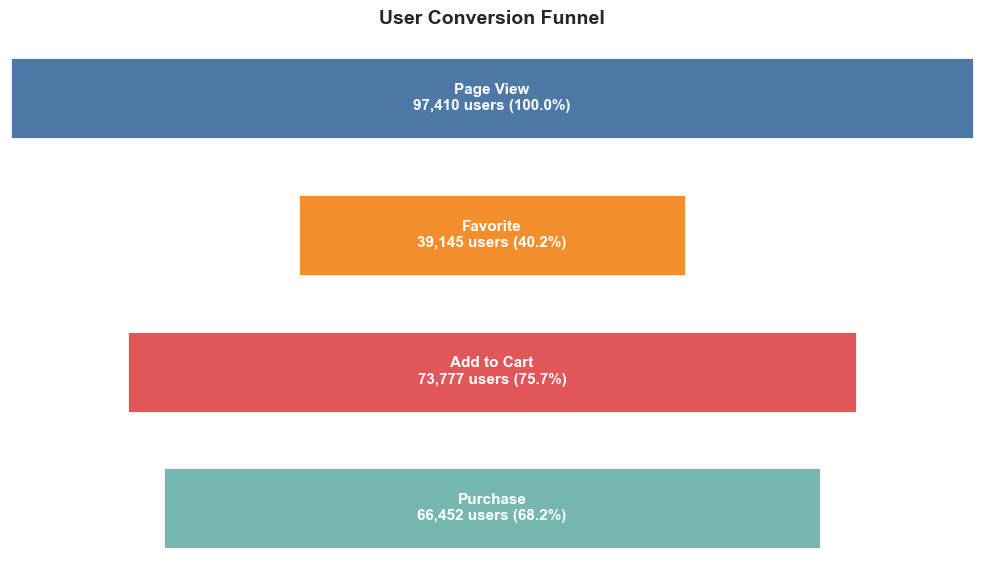

Figure 2 saved.


In [6]:
# ----- Fig 2: Conversion Funnel -----
# Calculate users who performed each behavior type
users_pv = df[df['behavior_type'] == 'pv']['user_id'].nunique()
users_fav = df[df['behavior_type'] == 'fav']['user_id'].nunique()
users_cart = df[df['behavior_type'] == 'cart']['user_id'].nunique()
users_buy = df[df['behavior_type'] == 'buy']['user_id'].nunique()

funnel_data = {
    'Stage': ['Page View', 'Favorite', 'Add to Cart', 'Purchase'],
    'Users': [users_pv, users_fav, users_cart, users_buy],
    'Pct of PV Users': [100.0, users_fav/users_pv*100, users_cart/users_pv*100, users_buy/users_pv*100]
}
funnel_df = pd.DataFrame(funnel_data)
print('Conversion Funnel (by unique users):')
print(funnel_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
stages = funnel_df['Stage']
pcts = funnel_df['Pct of PV Users']

# Horizontal funnel bars
for i, (stage, pct) in enumerate(zip(stages, pcts)):
    bar_width = pct / 100.0
    left = (1 - bar_width) / 2
    ax.barh(len(stages) - 1 - i, bar_width, left=left, height=0.6,
            color=colors[i], edgecolor='white', linewidth=2)
    ax.text(0.5, len(stages) - 1 - i,
            f'{stage}\n{funnel_df["Users"].iloc[i]:,} users ({pct:.1f}%)',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('User Conversion Funnel', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_conversion_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

> **Common Pitfall:** When computing conversion rates, be careful about what constitutes the denominator. Using *users* vs *sessions* vs *page views* yields very different funnel shapes. In this analysis, we use unique users at each stage.

## 4. Temporal Analysis

> **Concept:** User behavior on e-commerce platforms follows strong temporal patterns — daily cycles (peak hours), weekly patterns (weekday vs weekend), and macro trends (promotional events). Understanding these patterns informs feature engineering and the importance of *time-aware* sequence modeling.

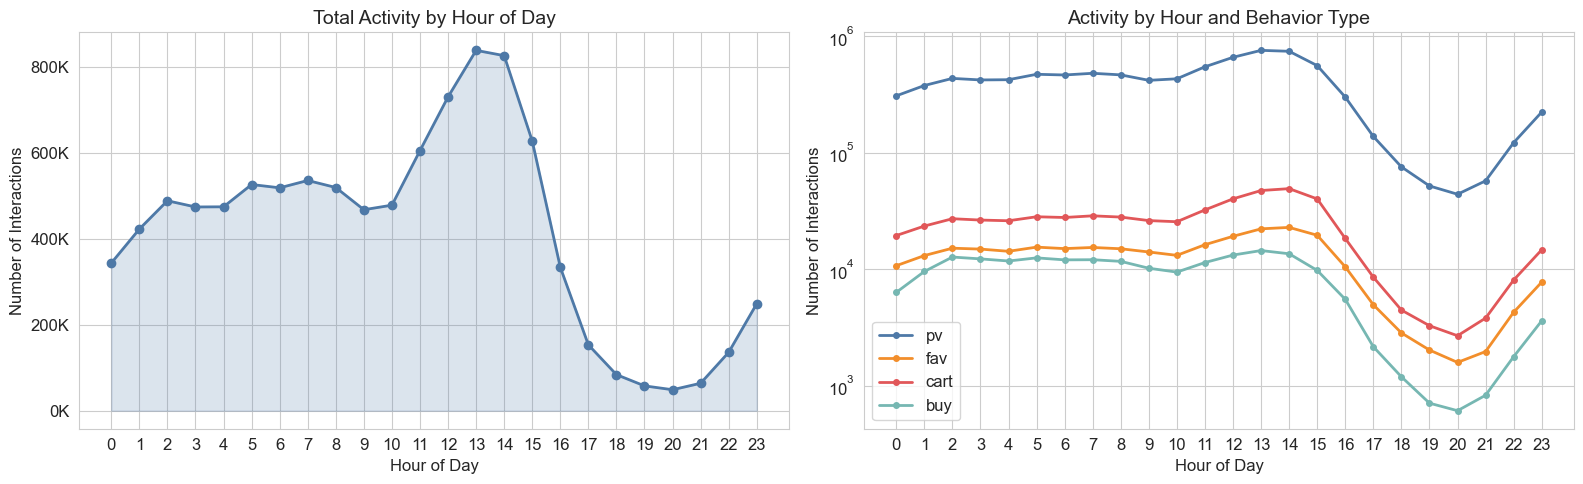

Figure 3 saved.


In [7]:
# ----- Fig 3: Hourly Activity Pattern -----
hourly_counts = df.groupby(['hour', 'behavior_type']).size().unstack(fill_value=0)
hourly_total = df.groupby('hour').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total activity by hour
axes[0].plot(hourly_total.index, hourly_total.values, 'o-', color='#4e79a7', linewidth=2, markersize=6)
axes[0].fill_between(hourly_total.index, hourly_total.values, alpha=0.2, color='#4e79a7')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Interactions')
axes[0].set_title('Total Activity by Hour of Day')
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Activity by hour and behavior type
for btype, color in zip(behavior_order, colors):
    if btype in hourly_counts.columns:
        axes[1].plot(hourly_counts.index, hourly_counts[btype], 'o-', label=btype, 
                     color=color, linewidth=2, markersize=4)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Interactions')
axes[1].set_title('Activity by Hour and Behavior Type')
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('fig3_hourly_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

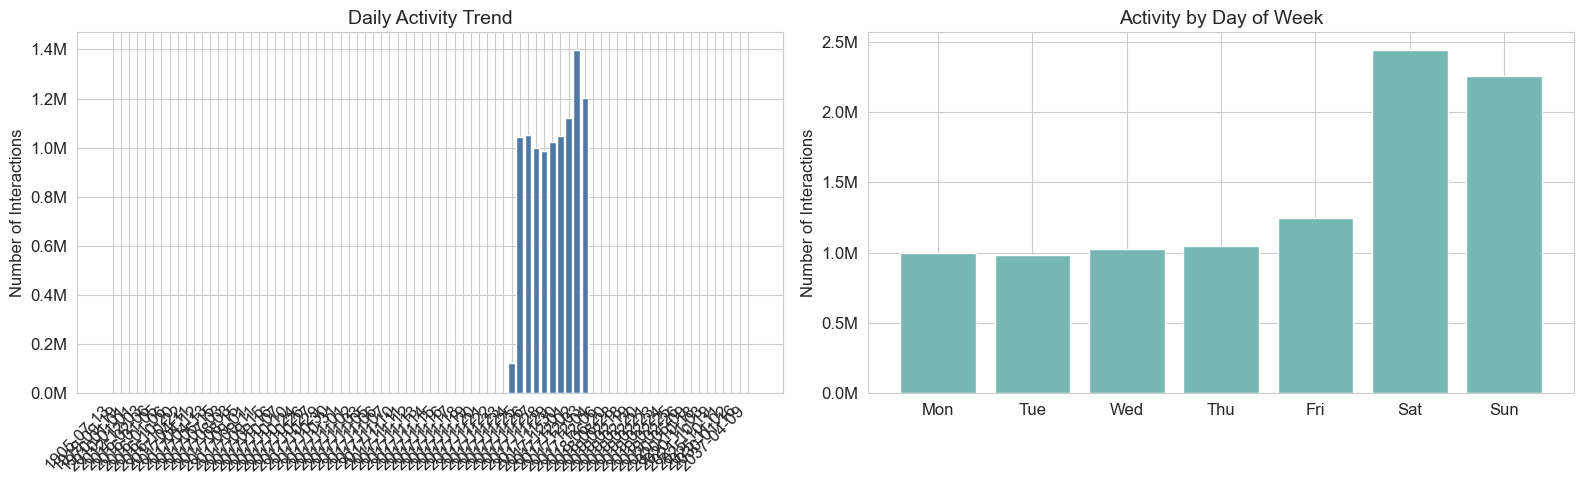

Figure 4 saved.


In [8]:
# ----- Fig 4: Daily Trend -----
daily_counts = df.groupby(['date', 'behavior_type']).size().unstack(fill_value=0)
daily_total = df.groupby('date').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Daily total
dates = sorted(daily_total.index)
axes[0].bar(range(len(dates)), [daily_total[d] for d in dates], color='#4e79a7', edgecolor='white')
axes[0].set_xticks(range(len(dates)))
axes[0].set_xticklabels([str(d) for d in dates], rotation=45, ha='right')
axes[0].set_ylabel('Number of Interactions')
axes[0].set_title('Daily Activity Trend')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Day of week
dow_counts = df.groupby('day_of_week').size()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(len(dow_counts)), dow_counts.values, color='#76b7b2', edgecolor='white')
axes[1].set_xticks(range(len(dow_counts)))
axes[1].set_xticklabels([dow_labels[i] for i in dow_counts.index])
axes[1].set_ylabel('Number of Interactions')
axes[1].set_title('Activity by Day of Week')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('fig4_daily_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 5. User Behavior Analysis

> **Concept:** User engagement in e-commerce typically follows a **power-law distribution** — a small fraction of highly active users generates a disproportionate share of interactions, while the majority of users have few interactions. This has direct implications for sequential model design: models must handle sequences of varying lengths.

In [9]:
# User-level statistics
user_stats = df.groupby('user_id').agg(
    n_interactions=('item_id', 'count'),
    n_unique_items=('item_id', 'nunique'),
    n_unique_categories=('category_id', 'nunique'),
    n_behaviors=('behavior_type', 'nunique'),
    first_action=('timestamp', 'min'),
    last_action=('timestamp', 'max')
).reset_index()

user_stats['active_span_hours'] = (user_stats['last_action'] - user_stats['first_action']) / 3600.0

print('User-level Statistics:')
print(user_stats[['n_interactions', 'n_unique_items', 'n_unique_categories']].describe().round(1))

User-level Statistics:
       n_interactions  n_unique_items  n_unique_categories
count         97811.0         97811.0              97811.0
mean            102.2            77.6                 24.6
std              87.2            64.3                 16.5
min               1.0             1.0                  1.0
25%              40.0            32.0                 13.0
50%              76.0            59.0                 21.0
75%             138.0           104.0                 32.0
max             792.0           710.0                199.0


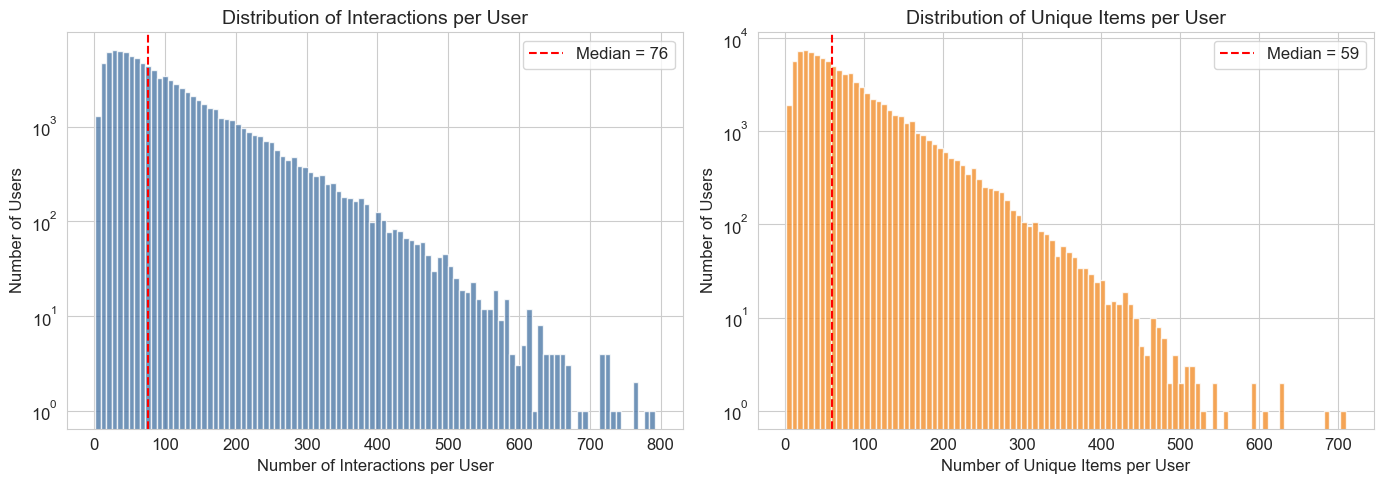

Figure 5 saved.


In [10]:
# ----- Fig 5: User Interaction Count Distribution -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log scale)
axes[0].hist(user_stats['n_interactions'], bins=100, color='#4e79a7', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Number of Interactions per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Distribution of Interactions per User')
axes[0].set_yscale('log')
axes[0].axvline(user_stats['n_interactions'].median(), color='red', linestyle='--', 
                label=f'Median = {user_stats["n_interactions"].median():.0f}')
axes[0].legend()

# Unique items per user
axes[1].hist(user_stats['n_unique_items'], bins=100, color='#f28e2b', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Number of Unique Items per User')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Distribution of Unique Items per User')
axes[1].set_yscale('log')
axes[1].axvline(user_stats['n_unique_items'].median(), color='red', linestyle='--',
                label=f'Median = {user_stats["n_unique_items"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig5_user_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [11]:
# Power-law analysis
interaction_counts = user_stats['n_interactions'].values
sorted_counts = np.sort(interaction_counts)[::-1]
rank = np.arange(1, len(sorted_counts) + 1)

# What % of users account for 80% of interactions?
cumsum = np.cumsum(sorted_counts)
total = cumsum[-1]
idx_80 = np.searchsorted(cumsum, 0.8 * total)
pct_users_80 = (idx_80 + 1) / len(sorted_counts) * 100

print(f'Top {pct_users_80:.1f}% of users account for 80% of all interactions')
print(f'This confirms the power-law / Pareto distribution of user activity.')

Top 49.8% of users account for 80% of all interactions
This confirms the power-law / Pareto distribution of user activity.


## 6. Item Popularity Analysis

In [12]:
# Item-level statistics
item_counts = df.groupby('item_id').size().reset_index(name='n_interactions')
item_counts_sorted = item_counts.sort_values('n_interactions', ascending=False).reset_index(drop=True)

print(f'Item popularity statistics:')
print(item_counts['n_interactions'].describe().round(1))
print(f'\nItems with only 1 interaction: {(item_counts["n_interactions"] == 1).sum():,} '
      f'({(item_counts["n_interactions"] == 1).mean()*100:.1f}%)')

Item popularity statistics:
count    1561016.0
mean           6.4
std           21.8
min            1.0
25%            1.0
50%            2.0
75%            5.0
max         3220.0
Name: n_interactions, dtype: float64

Items with only 1 interaction: 653,950 (41.9%)


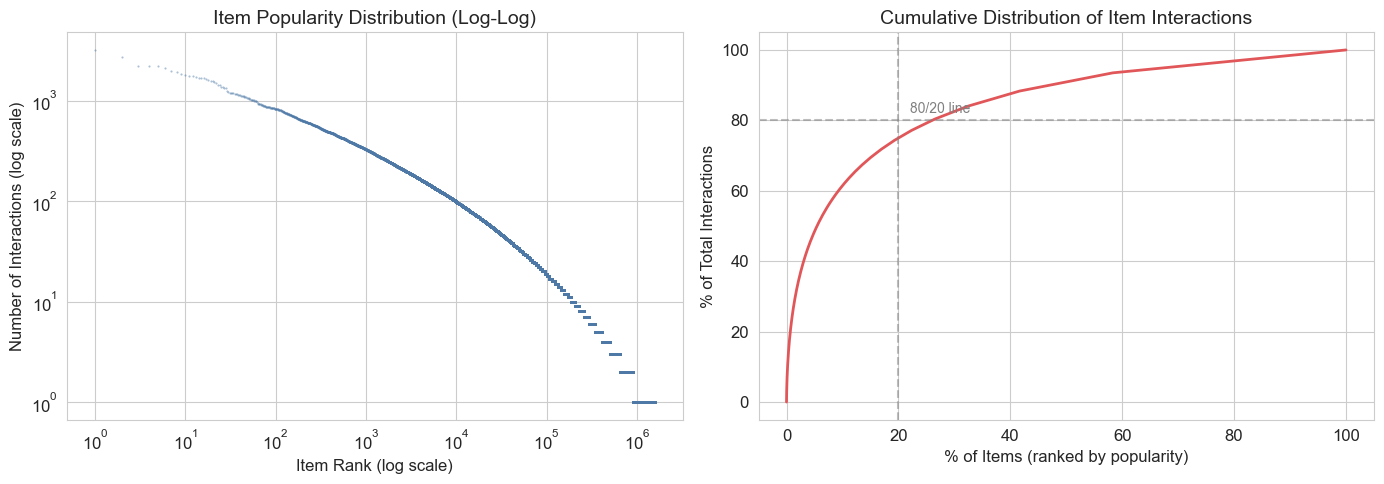

Figure 6 saved.


In [13]:
# ----- Fig 6: Item Popularity Long-Tail (log-log) -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-log plot
item_sorted = item_counts_sorted['n_interactions'].values
item_rank = np.arange(1, len(item_sorted) + 1)

axes[0].loglog(item_rank, item_sorted, '.', color='#4e79a7', markersize=1, alpha=0.5)
axes[0].set_xlabel('Item Rank (log scale)')
axes[0].set_ylabel('Number of Interactions (log scale)')
axes[0].set_title('Item Popularity Distribution (Log-Log)')

# CDF
cumsum_items = np.cumsum(item_sorted)
total_items = cumsum_items[-1]
axes[1].plot(item_rank / len(item_rank) * 100, cumsum_items / total_items * 100,
             color='#e15759', linewidth=2)
axes[1].set_xlabel('% of Items (ranked by popularity)')
axes[1].set_ylabel('% of Total Interactions')
axes[1].set_title('Cumulative Distribution of Item Interactions')
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(20, color='gray', linestyle='--', alpha=0.5)
axes[1].text(22, 82, '80/20 line', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('fig6_item_longtail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

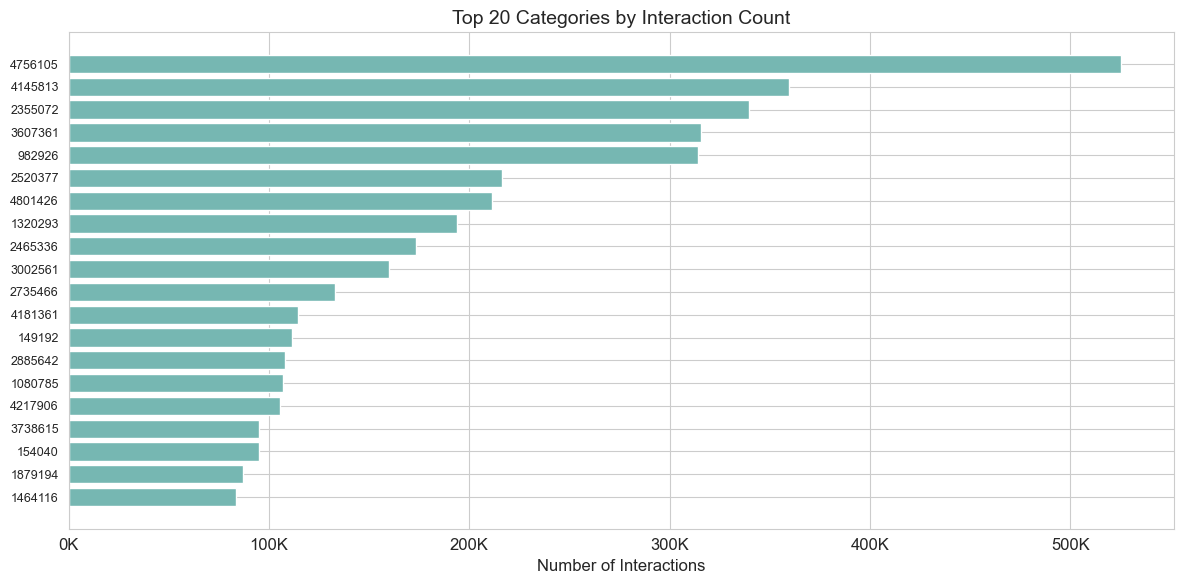

Total categories: 7,967
Top 20 categories account for 38.5% of all interactions
Figure 7 saved.


In [14]:
# ----- Fig 7: Category Distribution (Top-20) -----
category_counts = df.groupby('category_id').size().sort_values(ascending=False)
top20_cats = category_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top20_cats)), top20_cats.values, color='#76b7b2', edgecolor='white')
ax.set_yticks(range(len(top20_cats)))
ax.set_yticklabels([str(c) for c in top20_cats.index], fontsize=9)
ax.set_xlabel('Number of Interactions')
ax.set_title('Top 20 Categories by Interaction Count')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('fig7_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total categories: {len(category_counts):,}')
print(f'Top 20 categories account for {top20_cats.sum()/len(df)*100:.1f}% of all interactions')
print('Figure 7 saved.')

## 7. Sequence Length Analysis

> **Pro Tip:** When designing sequential models, the distribution of sequence lengths determines critical hyperparameters like `max_seq_len`. Setting it too low discards useful history; too high wastes computation and may introduce noise from stale interests.

In [15]:
# Compute sequence lengths (all behaviors per user, sorted by time)
seq_lengths = df.groupby('user_id').size()

print('Sequence Length Statistics:')
print(seq_lengths.describe().round(1))
print(f'\nPercentiles:')
for p in [50, 75, 90, 95, 99]:
    print(f'  {p}th percentile: {seq_lengths.quantile(p/100):.0f}')

Sequence Length Statistics:
count    97811.0
mean       102.2
std         87.2
min          1.0
25%         40.0
50%         76.0
75%        138.0
max        792.0
dtype: float64

Percentiles:
  50th percentile: 76
  75th percentile: 138
  90th percentile: 220
  95th percentile: 279
  99th percentile: 408


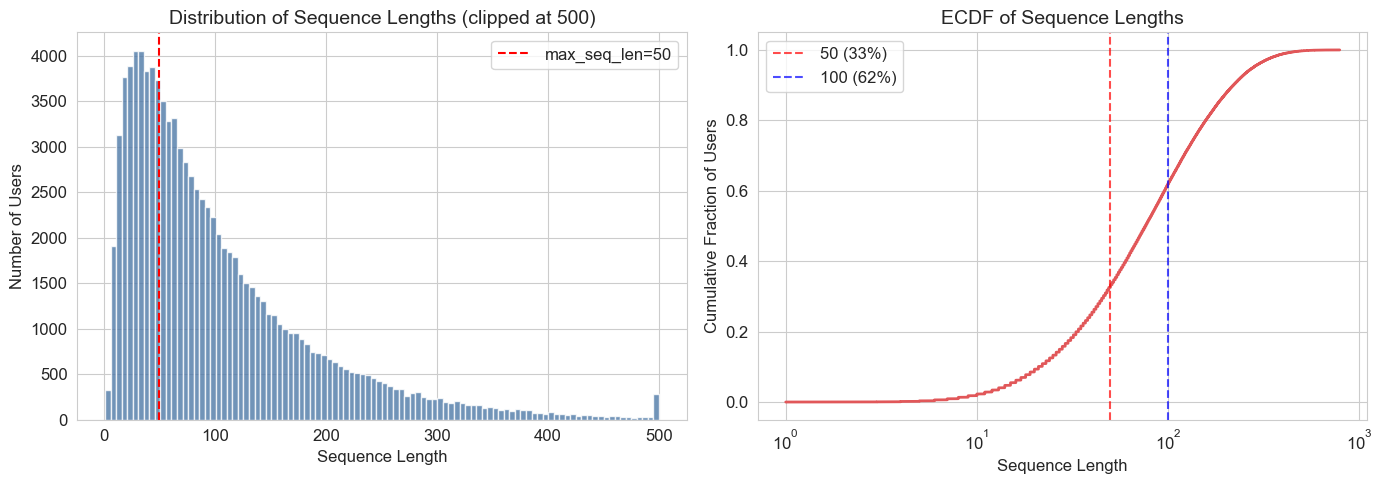

Figure 8 saved.


In [16]:
# ----- Fig 8: Sequence Length Distribution -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seq_lengths.clip(upper=500), bins=100, color='#4e79a7', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Distribution of Sequence Lengths (clipped at 500)')
axes[0].axvline(50, color='red', linestyle='--', label='max_seq_len=50')
axes[0].legend()

# What fraction of sequences are <=50?
pct_under_50 = (seq_lengths <= 50).mean() * 100
pct_under_100 = (seq_lengths <= 100).mean() * 100

# ECDF
sorted_lens = np.sort(seq_lengths.values)
ecdf_y = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens)
axes[1].plot(sorted_lens, ecdf_y, color='#e15759', linewidth=2)
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('Cumulative Fraction of Users')
axes[1].set_title('ECDF of Sequence Lengths')
axes[1].set_xscale('log')
axes[1].axvline(50, color='red', linestyle='--', alpha=0.7, label=f'50 ({pct_under_50:.0f}%)')
axes[1].axvline(100, color='blue', linestyle='--', alpha=0.7, label=f'100 ({pct_under_100:.0f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig8_sequence_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

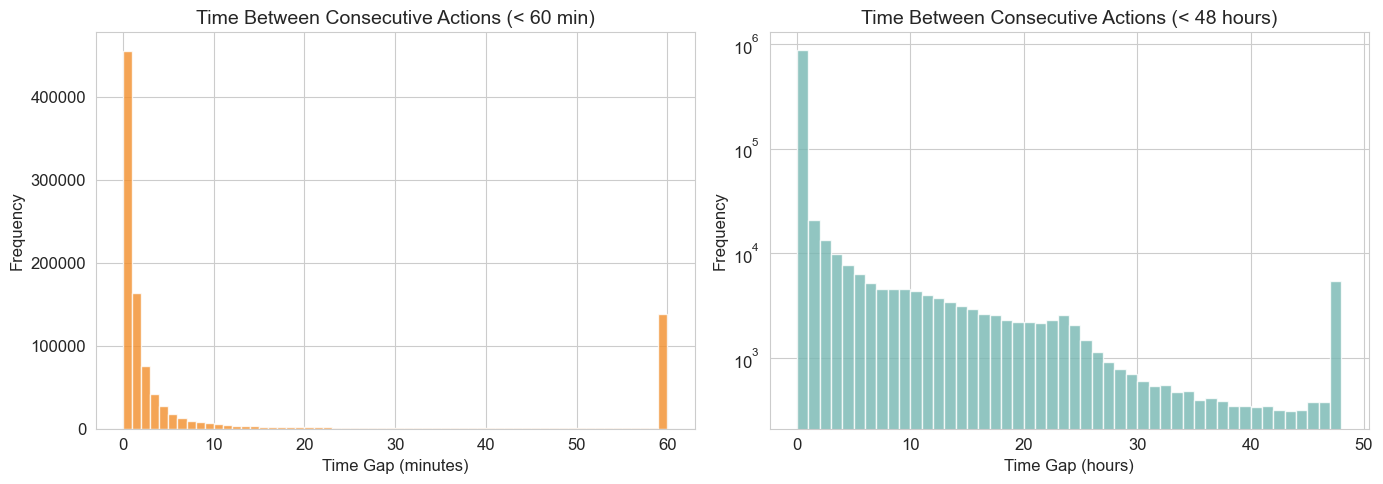

Median time gap: 1.2 minutes
Mean time gap: 1.9 hours
Figure 9 saved.


In [17]:
# ----- Fig 9: Time Gap Distribution Between Consecutive Actions -----
# Sample users for efficiency
sample_users = np.random.choice(df['user_id'].unique(), size=min(10000, n_users), replace=False)
df_sample = df[df['user_id'].isin(sample_users)].sort_values(['user_id', 'timestamp'])

df_sample['time_gap'] = df_sample.groupby('user_id')['timestamp'].diff()
time_gaps = df_sample['time_gap'].dropna()
time_gaps_minutes = time_gaps / 60.0  # Convert to minutes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes (clipped at 60 min)
axes[0].hist(time_gaps_minutes.clip(upper=60), bins=60, color='#f28e2b', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Time Gap (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Time Between Consecutive Actions (< 60 min)')

# Hours (log scale)
time_gaps_hours = time_gaps / 3600.0
axes[1].hist(time_gaps_hours.clip(upper=48), bins=48, color='#76b7b2', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Time Gap (hours)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Time Between Consecutive Actions (< 48 hours)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('fig9_time_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median time gap: {time_gaps_minutes.median():.1f} minutes')
print(f'Mean time gap: {time_gaps_hours.mean():.1f} hours')
print('Figure 9 saved.')

## 8. Data Preprocessing for Sequential Models

> **Concept:** For sequential recommendation, we need to transform raw interaction logs into *user behavior sequences* ordered by time. The standard evaluation protocol uses the **leave-one-out** strategy: the last interaction becomes the test target, the second-to-last the validation target, and all preceding interactions form the training history.

### Preprocessing Pipeline

1. **Filter**: Remove items with < 5 interactions and users with < 10 interactions
2. **Encode**: Label-encode `item_id` and `category_id` to contiguous integers (0..N-1)
3. **Sort**: Order interactions by user and timestamp
4. **Sequence**: Group interactions into per-user sequences
5. **Split**: Use the last interaction as the test sample

In [18]:
# Reload full 10M sample for processing
print('Starting preprocessing pipeline...')
print(f'Initial: {len(df):,} interactions, {df["user_id"].nunique():,} users, {df["item_id"].nunique():,} items')

# Step 1: Filter items with >= 5 interactions
item_counts_full = df.groupby('item_id').size()
valid_items = item_counts_full[item_counts_full >= 5].index
df_filtered = df[df['item_id'].isin(valid_items)].copy()
print(f'After item filter (>=5): {len(df_filtered):,} interactions, '
      f'{df_filtered["item_id"].nunique():,} items')

# Step 2: Filter users with >= 10 interactions
user_counts_full = df_filtered.groupby('user_id').size()
valid_users = user_counts_full[user_counts_full >= 10].index
df_filtered = df_filtered[df_filtered['user_id'].isin(valid_users)].copy()
print(f'After user filter (>=10): {len(df_filtered):,} interactions, '
      f'{df_filtered["user_id"].nunique():,} users, {df_filtered["item_id"].nunique():,} items')

Starting preprocessing pipeline...


Initial: 10,000,000 interactions, 97,811 users, 1,561,016 items


After item filter (>=5): 8,023,867 interactions, 410,462 items


After user filter (>=10): 7,995,757 interactions, 93,297 users, 410,452 items


In [19]:
# Step 3: Label encoding
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
cat_encoder = LabelEncoder()

df_filtered['user_idx'] = user_encoder.fit_transform(df_filtered['user_id'])
df_filtered['item_idx'] = item_encoder.fit_transform(df_filtered['item_id']) + 1  # 0 reserved for padding
df_filtered['cat_idx'] = cat_encoder.fit_transform(df_filtered['category_id']) + 1  # 0 reserved for padding

n_users_enc = df_filtered['user_idx'].nunique()
n_items_enc = df_filtered['item_idx'].max() + 1  # includes padding
n_cats_enc = df_filtered['cat_idx'].max() + 1

print(f'Encoded: {n_users_enc} users, {n_items_enc} items (with padding), {n_cats_enc} categories (with padding)')

Encoded: 93297 users, 410453 items (with padding), 5200 categories (with padding)


In [20]:
# Step 4: Sort and create sequences
df_filtered = df_filtered.sort_values(['user_idx', 'timestamp']).reset_index(drop=True)

# Create behavior encoding: pv=1, fav=2, cart=3, buy=4
behavior_map = {'pv': 1, 'fav': 2, 'cart': 3, 'buy': 4}
df_filtered['behavior_idx'] = df_filtered['behavior_type'].map(behavior_map)

print('Building user sequences...')
user_sequences = {}
for user_idx, group in df_filtered.groupby('user_idx'):
    user_sequences[user_idx] = {
        'item_ids': group['item_idx'].values.tolist(),
        'cat_ids': group['cat_idx'].values.tolist(),
        'behavior_types': group['behavior_idx'].values.tolist(),
        'timestamps': group['timestamp'].values.tolist()
    }

print(f'Created sequences for {len(user_sequences)} users')
avg_seq_len = np.mean([len(v['item_ids']) for v in user_sequences.values()])
print(f'Average sequence length: {avg_seq_len:.1f}')

Building user sequences...


Created sequences for 93297 users
Average sequence length: 85.7


In [21]:
# Step 5: Train/test split by time (last interaction as test)
# For each user, the last interaction is the test target
# The second-to-last is the validation target (optional)
# All preceding interactions form the training history

# Also compute item popularity for negative sampling
item_popularity = df_filtered.groupby('item_idx').size()
item_pop_prob = (item_popularity / item_popularity.sum()).to_dict()

# Save everything
processed_data = {
    'user_sequences': user_sequences,
    'n_users': n_users_enc,
    'n_items': n_items_enc,
    'n_categories': n_cats_enc,
    'item_popularity': item_pop_prob,
    'user_encoder': user_encoder,
    'item_encoder': item_encoder,
    'cat_encoder': cat_encoder,
}

save_path = os.path.join(PROCESSED_DIR, 'taobao_sequential_data.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(processed_data, f)

print(f'Saved processed data to {save_path}')
print(f'\nData summary:')
print(f'  Users: {n_users_enc:,}')
print(f'  Items: {n_items_enc:,} (including padding idx 0)')
print(f'  Categories: {n_cats_enc:,} (including padding idx 0)')
print(f'  Total sequences: {len(user_sequences):,}')
print(f'  Avg sequence length: {avg_seq_len:.1f}')

Saved processed data to ../../data/taobao/processed/taobao_sequential_data.pkl

Data summary:
  Users: 93,297
  Items: 410,453 (including padding idx 0)
  Categories: 5,200 (including padding idx 0)
  Total sequences: 93,297
  Avg sequence length: 85.7


## 9. Why Sequential Modeling?

> **Concept:** Traditional collaborative filtering treats user-item interactions as a **static matrix**, ignoring the order and timing of interactions. For e-commerce data like Taobao, this discards critical information:

### Key Arguments for Sequential Modeling

1. **Temporal Dynamics**: User interests evolve. A user browsing laptops today may shift to phone accessories tomorrow. The *order* of interactions encodes intent evolution.

2. **Short-term Intent**: The most recent actions are often the strongest signal. If a user just viewed 5 running shoes, they are likely looking for running shoes — not the books they bought last week.

3. **Behavior Heterogeneity**: Different behavior types (pv, cart, buy) carry different signals. A sequence of `[pv, pv, cart, pv, buy]` tells a richer story than just "5 interactions."

4. **Session Structure**: As we saw in the temporal analysis, users exhibit *sessions* — bursts of activity with gaps. Sequential models can capture intra-session patterns.

### From Data to Models

In the next notebooks, we will implement:

| Model | Key Idea | Attention Type |
|-------|----------|---------------|
| **DIN** | Target-aware attention over history | $\alpha_i = f(e_i, e_{target})$ |
| **BST** | Transformer encoder + target attention | Multi-head self-attention |
| **SASRec** | Causal self-attention for next-item | Masked self-attention |

Each model progressively captures richer sequential patterns, from target-specific relevance (DIN) to full pairwise dependencies (Transformers).

---

## Exercises

### Exercise 1: Behavior Transition Analysis
Compute the **transition probability matrix** between behavior types. For each pair (A, B), what fraction of behavior A is immediately followed by behavior B for the same user?

```python
# TODO: Your code here
# Hint: Use df.groupby('user_id') and compute consecutive behavior pairs
# Expected output: 4x4 transition matrix (pv, fav, cart, buy)
```

### Exercise 2: Session Detection
Define a *session* as a continuous period of activity with no gap longer than 30 minutes. Compute:
- Average number of sessions per user
- Average session length (number of interactions)
- Distribution of session lengths

```python
# TODO: Your code here
# Hint: Use the time_gap column and a threshold of 30 minutes (1800 seconds)
```

### Exercise 3: Repeat Purchase Analysis
What fraction of purchased items are *repeat purchases* (the same user buying the same item more than once)? How does this vary across categories?

```python
# TODO: Your code here
# Hint: Filter for behavior_type == 'buy', then groupby user_id and item_id
```

### Exercise 4: Category Co-occurrence
Build a category co-occurrence matrix: for each pair of categories, how many users interacted with both categories? Visualize the top-10 most co-occurring category pairs.

```python
# TODO: Your code here
# Hint: For each user, get the set of categories. Then count pairwise co-occurrences.
```

---

## Summary and Key Takeaways

1. **Dataset Scale**: The Taobao dataset contains ~100M interactions from hundreds of thousands of users across millions of items, providing a rich testbed for sequential recommendation.

2. **Behavior Diversity**: Page views dominate (~90%), with purchases comprising only ~2% of interactions. This extreme imbalance is typical of e-commerce and makes CTR prediction both important and challenging.

3. **Temporal Patterns**: Clear daily cycles (peak activity 8-10 PM) and weekly patterns provide context for understanding user engagement rhythms.

4. **Power-law Distributions**: Both user activity and item popularity follow heavy-tailed distributions, with a small fraction of entities accounting for the majority of interactions.

5. **Sequential Modeling Motivation**: The temporal structure, behavior heterogeneity, and evolving user interests strongly motivate sequential models over static collaborative filtering.

6. **Preprocessing Decisions**: Filtering thresholds (items >= 5, users >= 10), sequence length truncation (max 50), and negative sampling strategy are critical hyperparameters that directly impact model performance.

### Next Steps
In the next notebook, we implement **DIN (Deep Interest Network)**, which uses target-aware attention to adaptively weigh the relevance of each historical behavior for predicting clicks.